In [8]:
import json
import pandas as pd

In [3]:
json_file_path = "merged_details.json"
with open(json_file_path, 'r', encoding='utf-8') as j:
     contents = json.loads(j.read())

In [ ]:
users = pd.DataFrame(contents["users"])
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6640 entries, 0 to 6639
Data columns (total 77 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   profileData                                     6640 non-null   object 
 1   groupData                                       6640 non-null   object 
 2   mediaData                                       6640 non-null   object 
 3   position                                        4240 non-null   object 
 4   childLiveWithMe                                 6215 non-null   str    
 5   address                                         6302 non-null   str    
 6   myersBriggsPersonality                          3440 non-null   str    
 7   humanDesignType                                 5550 non-null   str    
 8   latlng                                          6302 non-null   str    
 9   heardAboutWhiteDate                             6266

As per my understanding, the json is arranged in this way:

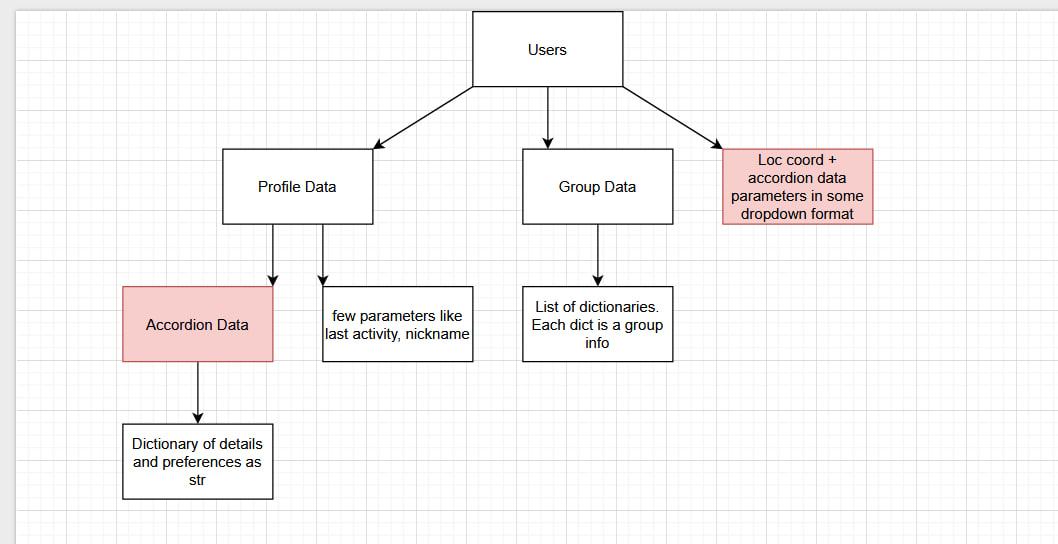

The red sections are repeated. I have verified on various random samples. The upper red box seems to contain data in some sort of dropdown format? Unsure.
So I am deleting the upper red box and only utilizing Accordion Data as it is stored in a more understandable format.

In [81]:
profileData = users["profileData"].apply(pd.Series)
accordionData = profileData["accordionData"].apply(pd.Series)

In [102]:
delete_columns = ["childLiveWithMe",
"address",
"myersBriggsPersonality",
"humanDesignType",
"latlng",
"heardAboutWhiteDate",
"howIFoundWD",
"lookingFor",
"thingsIAmLookingForInAPersonAre:",
"theOneThingIAmMostPassionateAbout:",
"language",
"spirituality",
"interests",
"politicalOrientation",
"mindset",
"diet",
"smoking",
"pets",
"stanceOnVaccination",
"geographicFlexibility",
"accomodation",
"openToPolygyny",
"favoriteVacationSpot",
"idealFirstDate",
"ancestry",
"race",
"humanPhenotypesNet",
"bodyType",
"hair",
"height",
"heightSlider",
"weight",
"eyeColor",
"bestFeatures",
"tattoos",
"piercings",
"bloodType",
"virginity",
"accordionData",
"profileData"]

In [109]:
users_flat = pd.concat([users, profileData, accordionData], axis=1)
users_flat.drop(columns = delete_columns, inplace=True)
users_flat.head()

,groupData,mediaData,position,id,friendship_status,friendship_status_slug,link,member_types,avatar_urls,_links,...,Piercings,Blood Type,Accomodation,Weight,Child(ren) live(s) with me,Virginity,Address,Heard about WhiteDate,How I found WD,Height Slider
0,"[{'name': 'General chat', 'url': 'https://www....",[],"{'latitude': 12.409887783985786, 'longitude': ...",11780.0,False,,https://www.whitedate.net/members-white-people...,[],{'full': 'https://www.whitedate.net/wp-content...,{'self': [{'href': 'https://www.whitedate.net/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[],[],"{'latitude': -2.7522047, 'longitude': 54.6639133}",8570.0,False,,https://www.whitedate.net/members-white-people...,[],{'full': '//www.gravatar.com/avatar/36d03f10d2...,{'self': [{'href': 'https://www.whitedate.net/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'name': 'General chat', 'url': 'https://www....",[],"{'latitude': 53.5510846, 'longitude': 9.9936819}",10193.0,False,,https://www.whitedate.net/members-white-people...,[],{'full': '//www.gravatar.com/avatar/b46ef46162...,{'self': [{'href': 'https://www.whitedate.net/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[],[],"{'latitude': 53.5510846, 'longitude': 9.9936818}",10854.0,False,,https://www.whitedate.net/members-white-people...,[],{'full': '//www.gravatar.com/avatar/8cff438ea5...,{'self': [{'href': 'https://www.whitedate.net/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'name': 'Rh-', 'url': 'https://www.whitedate...",[],"{'latitude': 52.336916, 'longitude': -6.4633381}",14919.0,False,,https://www.whitedate.net/members-white-people...,[],{'full': '//www.gravatar.com/avatar/583b59a67c...,{'self': [{'href': 'https://www.whitedate.net/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
users_flat["Political Orientation"].value_counts()

Political Orientation
Pro-White                                                                                                                                 605
Pro-White, National Socialism                                                                                                              33
Alt Right                                                                                                                                  29
Pro-White, Traditionalism                                                                                                                  26
Pro-White, Fully redpilled                                                                                                                 23
                                                                                                                                         ... 
Pro-White, Alt-Right, Fully redpilled, Based, Traditionalism, Ethnonationalism, Monarchism, National Socialism, Fascism       

In [119]:
users_flat["Stance on Vaccination"].value_counts()

Stance on Vaccination
Anti-Vax, Not Covid Vaxxed                       288
Not Covid Vaxxed                                 146
Anti-Vax                                         112
Depends, Not Covid Vaxxed                         36
                                                  35
Depends                                           33
Anti-Vax, Depends, Not Covid Vaxxed               16
Not sure                                           7
Depends, Covid Vaxxed                              6
Depends, Not sure                                  5
Anti-Vax, Covid Vaxxed                             5
Depends, Not sure, Not Covid Vaxxed                4
Pro-Vax, Covid Vaxxed                              3
Pro-Vax                                            2
Not sure, Not Covid Vaxxed                         2
Anti-Vax, Depends, Covid Vaxxed                    2
Covid Vaxxed                                       1
Not sure, Covid Vaxxed                             1
Pro-Vax, Depends, Not Co

In [123]:
users_flat["Interests"].value_counts()

Interests
                                                                                                                                                                                                                                                                                             22
Family                                                                                                                                                                                                                                                                                        8
a:0:{}                                                                                                                                                                                                                                                                                        6
Politics, Fitness                                                                                                             

In [128]:
users_flat["Hair"].value_counts()

Hair
Medium brown                                          151
Dark brown                                            117
Dark blonde                                           110
Medium blonde                                          69
Light brown                                            68
                                                     ... 
Dark blonde, Venetian blonde, Red, Chestnut, Short      1
Dark blonde, Red, Light brown                           1
Chestnut, Long                                          1
Chestnut, Dark brown, Long                              1
Red, Dark brown, Gray/White                             1
Name: count, Length: 205, dtype: int64

In [129]:
users_flat["Body Type"].value_counts()

Body Type
Athletic                                         376
Conventional                                     246
Slim                                              98
Athletic, Conventional                            62
Athletic, Slim                                    59
Stout                                             44
Conventional, Slim                                23
                                                  23
Hulking                                           20
Petite                                            15
Athletic, Conventional, Slim                      13
Slim, Petite                                      12
Corpulent                                         12
Athletic, Stout                                   12
Hulking, Athletic                                 11
Conventional, Stout                               10
a:0:{}                                             5
Athletic, Petite                                   4
Petite, Slim                        

In [130]:
users_flat["Best Features"].value_counts()

Best Features
My eyes                                                                259
Cannot decide                                                          176
My hair                                                                 50
My voice                                                                35
My hands                                                                34
                                                                        23
My eyes, My voice                                                       15
My legs                                                                 15
My backside                                                             15
My eyes, My hair                                                        13
a:0:{}                                                                  12
My toes                                                                 10
My back                                                                  9
My eyes, My

In [131]:
users_flat["Mindset"].value_counts()

Mindset
                                                                                                                                                                                                                                                                                                        37
Every Single Time, White Genocide                                                                                                                                                                                                                                                                        5
White Genocide                                                                                                                                                                                                                                                                                           4
White Genocide CT                                                                              

In [132]:
users_flat["Diet"].value_counts()

Diet
Anything                                   907
Healthy                                    242
Anything, Healthy                          230
Healthy, Paleo                              31
                                            22
                                          ... 
Anything, Healthy, Keto, Gluten Free         1
Healthy, Keto, Gluten Free                   1
Weston A. Price, Keto                        1
Healthy, Vegetarian, Vegan, Paleo, Keto      1
a:0:{}                                       1
Name: count, Length: 88, dtype: int64

In [136]:
users_flat["Eye Color"].value_counts()

Eye Color
Blue                               375
Brown                              232
Green                              169
Hazel                              168
Blue, Green                         49
Blue, Gray                          39
Green, Hazel                        24
                                    23
Gray                                19
Hazel, Brown                        15
Blue, Green, Gray                   11
Green, Brown                        11
Green, Gray                          7
Blue, Green, Hazel                   5
a:0:{}                               4
Brown, Hazel                         3
Brown, Green                         2
Gray, Green                          2
Blue, Hazel                          2
Gray, Green, Hazel                   1
Blue, Green, Hazel, Brown            1
Blue, Gray, Hazel                    1
Blue, Green, Gray, Hazel, Brown      1
Blue, Gray, Green                    1
Blue, Green, Gray, Hazel             1
Green, Gray, Br

In [140]:
users_flat["Language"].value_counts()

Language
English                                  549
English, German                          100
English, French                           57
English, Spanish                          33
                                          22
                                        ... 
English, German, Greek                     1
English, Italian, Portugese, Spanish       1
Czech, English                             1
Danish, English, Icelandic, Norwegian      1
Serbo-Croatian                             1
Name: count, Length: 163, dtype: int64

In [141]:
users_flat["Spirituality"].value_counts()

Spirituality
Christian                                                                                                  198
Pagan                                                                                                       99
Other                                                                                                       97
Catholic                                                                                                    78
Agnostic                                                                                                    60
                                                                                                          ... 
Protestant, Wotanist, Agnostic                                                                               1
Christian, Catholic, Protestant, Orthodox Christian, Mormon, Other                                           1
Pagan, Atheist, Other                                                                              

Entities identified:

1. User - Basic information about the user + preferences, etc
2. Group Data - Information about various groups that a user can join. Many to Many relation with User
3. Political Orientation - List of Categories, Many to Many relation with User
4. Stance on Vaccination - List of Categories, Many to Many relation with User
5. Interests -  List of Categories, Many to Many relation with User
6. Hair - List of Categories, Many to Many relation with User
7. Body Type - List of Categories, Many to Many relation with User
8. Best Features - List of Categories, Many to Many relation with User
9. Mindset - List of Categories, Many to Many relation with User
10. Diet - List of Categories, Many to Many relation with User
11. Eye color - List of Categories, Many to Many relation with User
12. Language - List of Categories, Many to Many relation with User
13. Spirituality - List of Categories, Many to Many relation with User